# Внедрение ИИ и производительность компаний

### Анализ данных опросов российских предприятий за 2023–2024 годы

В проекте исследуется связь между использованием технологий искусственного интеллекта и ростом производительности российских предприятий.

Анализ основан на двух волнах опросов предприятий за 2023 и 2024 годы. Помимо анализа каждой волны отдельно, была сформирована панельная выборка компаний, участвовавших в опросе в обоих годах.

## Исследовательский вопрос

Связано ли использование искусственного интеллекта с более высокой вероятностью роста производительности предприятия и сохраняется ли эта связь при наблюдении одних и тех же компаний во времени?

## Данные

В исследовании используются две волны опроса российских предприятий:

- **2023 год:** 1 200 предприятий;
- **2024 год:** 1 212 предприятий.

Опрос содержит информацию об использовании технологий искусственного интеллекта, динамике производительности труда, размере и отрасли предприятия, а также других характеристиках бизнеса.

Для описательных показателей используются предоставленные в исходных данных веса выборки.

Исходные микроданные не публикуются в репозитории из-за ограничений конфиденциальности.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=UnicodeWarning)

df_2023 = pd.read_stata(
    "../data/2023_data_w_weights.dta",
    convert_categoricals=False
)

df_2024 = pd.read_stata(
    "../data/2024_data_w_weights.dta",
    convert_categoricals=False
)

print(f"2023: {df_2023.shape[0]:,} предприятий")
print(f"2024: {df_2024.shape[0]:,} предприятий")

2023: 1,200 предприятий
2024: 1,212 предприятий


## Подготовка данных

Для анализа были сформированы следующие основные переменные:

- **AI use** — предприятие использует хотя бы одну технологию искусственного интеллекта;
- **Productivity growth** — предприятие сообщило о росте производительности труда относительно предыдущего года;
- **Firm size** — логарифм среднесписочной численности работников;
- **Industry group** — укрупнённая отраслевая группа предприятия.

Ответы «затрудняюсь ответить» исключаются из соответствующих расчётов.

In [2]:
def create_ai_use(df, prefix):
    ai_cols = [f"{prefix}{i}" for i in range(1, 8)]

    result = pd.Series(np.nan, index=df.index)

    # Предприятие явно указало, что ИИ не используется
    result[df[f"{prefix}97"] == 1] = 0

    # Используется хотя бы одна из перечисленных
    # или другая технология ИИ
    uses_ai = (
        (df[ai_cols].max(axis=1) == 1)
        | (df[f"{prefix}98"] == 1)
    )

    result[uses_ai] = 1

    return result


def create_productivity_growth(series):
    result = pd.Series(np.nan, index=series.index)

    # Производительность снизилась или не изменилась
    result[series.isin([1, 2, 3])] = 0

    # Производительность выросла
    result[series.isin([4, 5])] = 1

    return result


def create_industry_group(series):
    mapping = {}

    for code in [1, 2]:
        mapping[code] = "Extractive"

    for code in [
        3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 14, 15, 131, 132
    ]:
        mapping[code] = "Manufacturing & energy"

    mapping[16] = "Construction"
    mapping[17] = "Trade"
    mapping[18] = "Transport"
    mapping[19] = "Finance"
    mapping[20] = "Business services"

    return series.map(mapping)


# Оставляем только необходимые для проекта столбцы
base_columns = [
    "inn",
    "changeproduct",
    "weight",
    "nempl",
    "industry"
]

analysis_2023 = df_2023[base_columns].copy()
analysis_2024 = df_2024[base_columns].copy()

# Использование ИИ
analysis_2023["ai_use"] = create_ai_use(df_2023, "Al_")
analysis_2024["ai_use"] = create_ai_use(df_2024, "ai_")

# Рост производительности
analysis_2023["productivity_growth"] = create_productivity_growth(
    analysis_2023["changeproduct"]
)

analysis_2024["productivity_growth"] = create_productivity_growth(
    analysis_2024["changeproduct"]
)

# Размер предприятия
analysis_2023["log_size"] = np.log(analysis_2023["nempl"])
analysis_2024["log_size"] = np.log(analysis_2024["nempl"])

# Укрупнённая отрасль
analysis_2023["industry_group"] = create_industry_group(
    analysis_2023["industry"]
)

analysis_2024["industry_group"] = create_industry_group(
    analysis_2024["industry"]
)

print("2023")
print(
    "AI status known:",
    analysis_2023["ai_use"].notna().sum(),
    "| Productivity known:",
    analysis_2023["productivity_growth"].notna().sum()
)

print("\n2024")
print(
    "AI status known:",
    analysis_2024["ai_use"].notna().sum(),
    "| Productivity known:",
    analysis_2024["productivity_growth"].notna().sum()
)

2023
AI status known: 1149 | Productivity known: 1156

2024
AI status known: 1192 | Productivity known: 1157


## Описательный анализ

Сначала сравним долю предприятий, сообщивших о росте производительности, среди компаний, использующих и не использующих ИИ.

Для этого сравнения используются веса выборки.

In [3]:
def weighted_growth_rate(df, ai_value):
    subset = df[
        (df["ai_use"] == ai_value) &
        (df["productivity_growth"].notna()) &
        (df["weight"].notna())
    ]

    return (
        (subset["productivity_growth"] * subset["weight"]).sum()
        / subset["weight"].sum()
        * 100
    )


rates = pd.DataFrame({
    "Year": ["2023", "2024"],
    "No AI": [
        weighted_growth_rate(analysis_2023, 0),
        weighted_growth_rate(analysis_2024, 0)
    ],
    "AI": [
        weighted_growth_rate(analysis_2023, 1),
        weighted_growth_rate(analysis_2024, 1)
    ]
})

rates["Difference, p.p."] = rates["AI"] - rates["No AI"]

display(
    rates.style.format({
        "No AI": "{:.2f}%",
        "AI": "{:.2f}%",
        "Difference, p.p.": "{:+.2f}"
    })
)

,Year,No AI,AI,"Difference, p.p."
0,2023,31.91%,22.96%,-8.95
1,2024,26.62%,35.30%,+8.68


### Первые наблюдения

В 2023 году доля предприятий, сообщивших о росте производительности, была ниже среди компаний, использующих ИИ: **22,96% против 31,91%** у компаний без ИИ.

В 2024 году картина изменилась: среди предприятий с ИИ рост производительности отметили **35,30%**, тогда как среди предприятий без ИИ — **26,62%**.

Таким образом, простое описательное сравнение показывает изменение направления связи между использованием ИИ и ростом производительности между двумя волнами опроса. Однако эти различия нельзя интерпретировать как причинный эффект ИИ, поскольку группы предприятий могут различаться по размеру, отрасли и другим характеристикам.

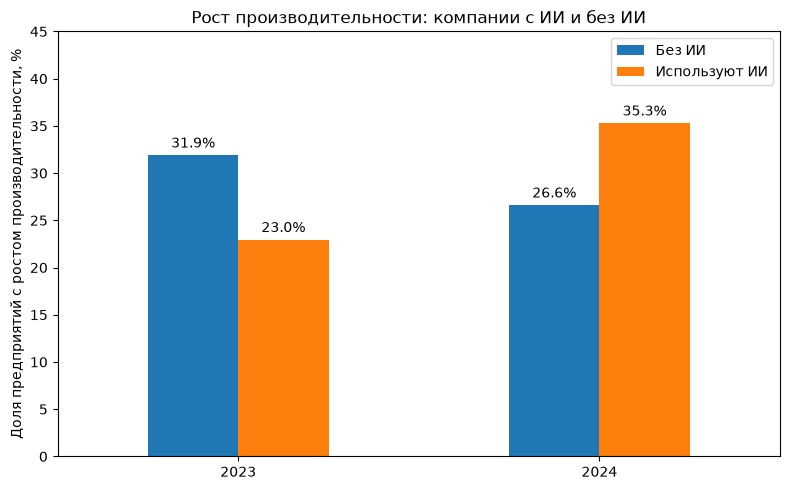

In [4]:
from pathlib import Path

figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

ax = (
    rates
    .set_index("Year")[["No AI", "AI"]]
    .plot(
        kind="bar",
        figsize=(8, 5)
    )
)

ax.set_title("Рост производительности: компании с ИИ и без ИИ")
ax.set_ylabel("Доля предприятий с ростом производительности, %")
ax.set_xlabel("")
ax.set_ylim(0, 45)
ax.legend(["Без ИИ", "Используют ИИ"], title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figures_dir / "01_productivity_growth_ai_vs_no_ai.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Регрессионный анализ

Простое сравнение групп не учитывает различия между предприятиями. В частности, компании, использующие ИИ, могут отличаться по размеру и отраслевой структуре.

Поэтому отдельно для 2023 и 2024 годов оценивается логистическая регрессия, где:

- зависимая переменная — наличие роста производительности;
- основная объясняющая переменная — использование ИИ;
- контрольные переменные — размер предприятия и укрупнённая отрасль.

Результаты интерпретируются как статистическая связь, а не как причинный эффект ИИ.

In [5]:
def fit_logit_model(df):
    model_data = df[
        [
            "productivity_growth",
            "ai_use",
            "log_size",
            "industry_group"
        ]
    ].dropna()

    model = smf.glm(
        formula=(
            "productivity_growth "
            "~ ai_use "
            "+ log_size "
            "+ C(industry_group)"
        ),
        data=model_data,
        family=sm.families.Binomial()
    ).fit()

    return model, model_data


model_2023, model_2023_data = fit_logit_model(analysis_2023)
model_2024, model_2024_data = fit_logit_model(analysis_2024)


regression_results = pd.DataFrame({
    "Год": [2023, 2024],
    "N": [
        len(model_2023_data),
        len(model_2024_data)
    ],
    "Коэффициент AI": [
        model_2023.params["ai_use"],
        model_2024.params["ai_use"]
    ],
    "p-value": [
        model_2023.pvalues["ai_use"],
        model_2024.pvalues["ai_use"]
    ]
})

display(
    regression_results.style.format({
        "Коэффициент AI": "{:+.3f}",
        "p-value": "{:.4f}"
    })
)

,Год,N,Коэффициент AI,p-value
0,2023,1107,-0.487,0.0012
1,2024,1143,+0.381,0.0056


In [6]:
def adjusted_probabilities(model, data, ai_column):
    no_ai = data.copy()
    no_ai[ai_column] = 0

    with_ai = data.copy()
    with_ai[ai_column] = 1

    prob_no_ai = model.predict(no_ai).mean() * 100
    prob_ai = model.predict(with_ai).mean() * 100

    return prob_no_ai, prob_ai, prob_ai - prob_no_ai


no_ai_2023, ai_2023, diff_2023 = adjusted_probabilities(
    model_2023,
    model_2023_data,
    "ai_use"
)

no_ai_2024, ai_2024, diff_2024 = adjusted_probabilities(
    model_2024,
    model_2024_data,
    "ai_use"
)


adjusted_results = pd.DataFrame({
    "Год": [2023, 2024],
    "Без ИИ": [no_ai_2023, no_ai_2024],
    "С ИИ": [ai_2023, ai_2024],
    "Разница, п.п.": [diff_2023, diff_2024]
})

display(
    adjusted_results.style.format({
        "Без ИИ": "{:.2f}%",
        "С ИИ": "{:.2f}%",
        "Разница, п.п.": "{:+.2f}"
    })
)

,Год,Без ИИ,С ИИ,"Разница, п.п."
0,2023,34.06%,24.30%,-9.76
1,2024,27.41%,35.52%,+8.11


### Скорректированные результаты

После учёта размера предприятия и отраслевой принадлежности различия между группами сохраняются.

В 2023 году использование ИИ было связано с **9,76 п.п. более низкой** скорректированной вероятностью роста производительности.

В 2024 году направление связи изменилось: использование ИИ было связано с **8,11 п.п. более высокой** скорректированной вероятностью роста производительности.

Результаты показывают изменение характера связи между использованием ИИ и производительностью между двумя волнами опроса, однако не позволяют сделать причинный вывод о влиянии ИИ.

## Панельный анализ

Чтобы проверить устойчивость результата во времени, предприятия из двух волн были сопоставлены по ИНН.

Во избежание неоднозначного сопоставления из панельной части исключались ИНН, встречавшиеся более одного раза внутри одной волны.

В результате удалось однозначно сопоставить **545 предприятий**, участвовавших в опросе как в 2023, так и в 2024 году.

Основной вопрос этого блока: связано ли использование ИИ в 2023 году с вероятностью роста производительности того же предприятия в 2024 году?

In [10]:
def keep_unique_inn(df):
    counts = df["inn"].value_counts()
    unique_inn = counts[counts == 1].index

    return df[df["inn"].isin(unique_inn)].copy()


unique_2023 = keep_unique_inn(analysis_2023)
unique_2024 = keep_unique_inn(analysis_2024)


panel_2023 = unique_2023[
    [
        "inn",
        "ai_use",
        "productivity_growth",
        "changeproduct",
        "log_size",
        "industry_group"
    ]
].rename(columns={
    "ai_use": "ai_use_2023",
    "productivity_growth": "productivity_growth_2023",
    "changeproduct": "changeproduct_2023",
    "log_size": "log_size_2023",
    "industry_group": "industry_group_2023"
})


panel_2024 = unique_2024[
    [
        "inn",
        "ai_use",
        "productivity_growth",
        "changeproduct"
    ]
].rename(columns={
    "ai_use": "ai_use_2024",
    "productivity_growth": "productivity_growth_2024",
    "changeproduct": "changeproduct_2024"
})


panel = panel_2023.merge(
    panel_2024,
    on="inn",
    how="inner"
)

print(f"Однозначно сопоставлено предприятий: {len(panel)}")

Однозначно сопоставлено предприятий: 545


### Связь использования ИИ с последующим ростом производительности

Для основной панельной модели используются предприятия, для которых известны:

- использование ИИ в 2023 году;
- рост производительности в 2024 году;
- размер предприятия в 2023 году;
- отрасль;
- динамика производительности в 2023 году.

Включение предыдущей динамики производительности позволяет частично учесть тот факт, что компании могли различаться по результативности ещё до рассматриваемого периода.

In [11]:
panel_model_data = panel[
    [
        "productivity_growth_2024",
        "ai_use_2023",
        "productivity_growth_2023",
        "log_size_2023",
        "industry_group_2023"
    ]
].dropna()


panel_model = smf.glm(
    formula=(
        "productivity_growth_2024 "
        "~ ai_use_2023 "
        "+ productivity_growth_2023 "
        "+ log_size_2023 "
        "+ C(industry_group_2023)"
    ),
    data=panel_model_data,
    family=sm.families.Binomial()
).fit()


panel_results = pd.DataFrame({
    "Показатель": [
        "Количество предприятий",
        "Коэффициент AI",
        "p-value"
    ],
    "Значение": [
        len(panel_model_data),
        panel_model.params["ai_use_2023"],
        panel_model.pvalues["ai_use_2023"]
    ]
})

display(panel_results)

,Показатель,Значение
0,Количество предприятий,486.000000
1,Коэффициент AI,0.726990
2,p-value,0.001393


In [12]:
panel_no_ai = panel_model_data.copy()
panel_no_ai["ai_use_2023"] = 0

panel_with_ai = panel_model_data.copy()
panel_with_ai["ai_use_2023"] = 1

prob_no_ai = panel_model.predict(panel_no_ai).mean() * 100
prob_with_ai = panel_model.predict(panel_with_ai).mean() * 100
difference = prob_with_ai - prob_no_ai


panel_adjusted_results = pd.DataFrame({
    "Сценарий": [
        "Без использования ИИ в 2023",
        "С использованием ИИ в 2023"
    ],
    "Скорректированная вероятность роста в 2024": [
        prob_no_ai,
        prob_with_ai
    ]
})

display(
    panel_adjusted_results.style.format({
        "Скорректированная вероятность роста в 2024": "{:.2f}%"
    })
)

print(f"\nРазница: {difference:+.2f} п.п.")

,Сценарий,Скорректированная вероятность роста в 2024
0,Без использования ИИ в 2023,19.23%
1,С использованием ИИ в 2023,31.99%



Разница: +12.76 п.п.


### Основной результат

В панельной выборке из **486 предприятий** использование ИИ в 2023 году связано с более высокой вероятностью роста производительности того же предприятия в 2024 году.

После учёта размера предприятия, отрасли и предыдущей динамики производительности скорректированная вероятность роста составляет:

- **19,23%** для предприятий без ИИ;
- **31,99%** для предприятий, использовавших ИИ.

Разница составляет **+12,76 п.п.** (`p ≈ 0,001`).

Результат следует интерпретировать как статистическую связь, а не как причинный эффект: наблюдательные данные не позволяют полностью исключить влияние ненаблюдаемых различий между предприятиями.

## Проверка устойчивости результата

В основном анализе показатель производительности был преобразован в бинарную переменную: рост / отсутствие роста.

Чтобы проверить, не зависит ли результат от такой бинаризации, дополнительно используется исходная пятиуровневая шкала:

1. значительно снизилась;
2. снизилась;
3. не изменилась;
4. повысилась;
5. значительно повысилась.

Для этой проверки оценивается порядковая логистическая регрессия (Ordered Logit) на той же панельной выборке.

In [13]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

ordinal_data = panel[
    [
        "changeproduct_2024",
        "ai_use_2023",
        "productivity_growth_2023",
        "log_size_2023",
        "industry_group_2023"
    ]
].copy()

# 99 = "затрудняюсь ответить"
ordinal_data["changeproduct_2024"] = (
    ordinal_data["changeproduct_2024"]
    .replace(99, np.nan)
)

ordinal_data = ordinal_data.dropna()

# Преобразуем отрасли в dummy-переменные
industry_dummies = pd.get_dummies(
    ordinal_data["industry_group_2023"],
    prefix="industry",
    drop_first=True,
    dtype=float
)

X = pd.concat(
    [
        ordinal_data[
            [
                "ai_use_2023",
                "productivity_growth_2023",
                "log_size_2023"
            ]
        ].astype(float),
        industry_dummies
    ],
    axis=1
)

y = ordinal_data["changeproduct_2024"].astype(int)

ordered_model = OrderedModel(
    y,
    X,
    distr="logit"
)

ordered_result = ordered_model.fit(
    method="bfgs",
    disp=False
)

robustness_results = pd.DataFrame({
    "Показатель": [
        "Количество предприятий",
        "Коэффициент AI",
        "p-value"
    ],
    "Значение": [
        len(ordinal_data),
        ordered_result.params["ai_use_2023"],
        ordered_result.pvalues["ai_use_2023"]
    ]
})

display(robustness_results)

,Показатель,Значение
0,Количество предприятий,486.000000
1,Коэффициент AI,0.502215
2,p-value,0.012752


### Результат проверки устойчивости

Результат сохраняется и при использовании исходной пятиуровневой шкалы производительности.

В Ordered Logit коэффициент при использовании ИИ в 2023 году остаётся положительным (`β ≈ 0,50`) и статистически значимым (`p ≈ 0,013`).

Таким образом, основной вывод не является следствием выбранного способа бинаризации показателя производительности: положительная связь между использованием ИИ и последующей динамикой производительности наблюдается и при сохранении исходной порядковой шкалы.

## Сравнение скорректированных результатов

На графике ниже показаны модельные вероятности роста производительности для предприятий с ИИ и без ИИ после учёта контрольных переменных.

Для панельной модели дополнительно учитывается предыдущая динамика производительности предприятия.

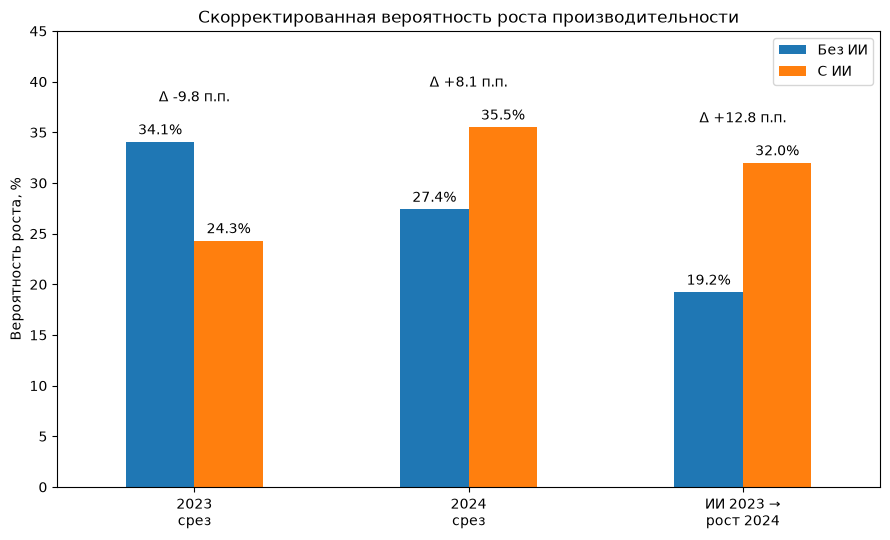

In [14]:
# Скорректированные вероятности для 2023
no_ai_2023, ai_2023, diff_2023 = adjusted_probabilities(
    model_2023,
    model_2023_data,
    "ai_use"
)

# Скорректированные вероятности для 2024
no_ai_2024, ai_2024, diff_2024 = adjusted_probabilities(
    model_2024,
    model_2024_data,
    "ai_use"
)

# Скорректированные вероятности для панельной модели
no_ai_panel, ai_panel, diff_panel = adjusted_probabilities(
    panel_model,
    panel_model_data,
    "ai_use_2023"
)

plot_rates = pd.DataFrame({
    "Модель": [
        "2023\nсрез",
        "2024\nсрез",
        "ИИ 2023 →\nрост 2024"
    ],
    "Без ИИ": [
        no_ai_2023,
        no_ai_2024,
        no_ai_panel
    ],
    "С ИИ": [
        ai_2023,
        ai_2024,
        ai_panel
    ]
})

ax = (
    plot_rates
    .set_index("Модель")[["Без ИИ", "С ИИ"]]
    .plot(
        kind="bar",
        figsize=(9, 5.5)
    )
)

ax.set_title("Скорректированная вероятность роста производительности")
ax.set_ylabel("Вероятность роста, %")
ax.set_xlabel("")
ax.set_ylim(0, 45)
ax.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

differences = plot_rates["С ИИ"] - plot_rates["Без ИИ"]

for i, diff in enumerate(differences):
    max_height = max(
        plot_rates.loc[i, "С ИИ"],
        plot_rates.loc[i, "Без ИИ"]
    )

    ax.text(
        i,
        max_height + 4,
        f"Δ {diff:+.1f} п.п.",
        ha="center"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figures_dir / "02_adjusted_productivity_growth.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Устойчивость оценок

Для трёх основных логистических моделей ниже показаны отношения шансов (odds ratio) и 95% доверительные интервалы для переменной использования ИИ.

Значение `OR = 1` соответствует отсутствию связи. Если доверительный интервал не пересекает 1, оценка статистически значимо отличается от нуля на соответствующем уровне значимости.

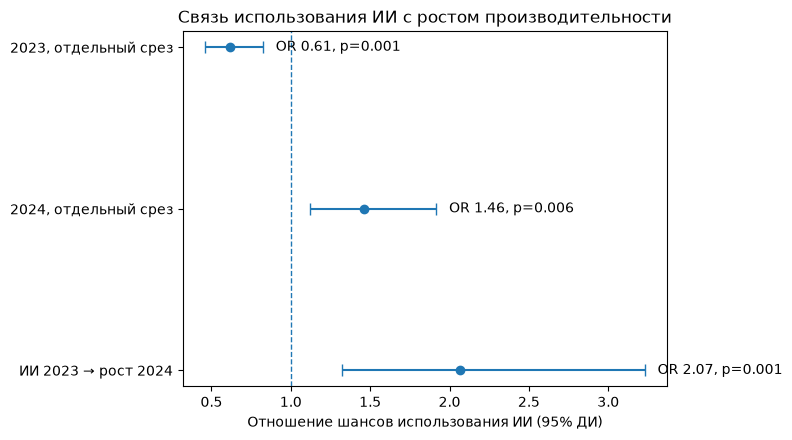

In [15]:
effect_models = [
    ("2023, отдельный срез", model_2023, "ai_use"),
    ("2024, отдельный срез", model_2024, "ai_use"),
    ("ИИ 2023 → рост 2024", panel_model, "ai_use_2023")
]

effect_rows = []

for name, model, variable in effect_models:
    coef = model.params[variable]
    ci_low, ci_high = model.conf_int().loc[variable]
    p_value = model.pvalues[variable]

    effect_rows.append({
        "Модель": name,
        "OR": np.exp(coef),
        "OR_low": np.exp(ci_low),
        "OR_high": np.exp(ci_high),
        "p_value": p_value
    })

effects = pd.DataFrame(effect_rows)

plot_effects = effects.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4.5))

xerr = [
    plot_effects["OR"] - plot_effects["OR_low"],
    plot_effects["OR_high"] - plot_effects["OR"]
]

ax.errorbar(
    plot_effects["OR"],
    range(len(plot_effects)),
    xerr=xerr,
    fmt="o",
    capsize=4
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1
)

ax.set_yticks(range(len(plot_effects)))
ax.set_yticklabels(plot_effects["Модель"])

ax.set_xlabel("Отношение шансов использования ИИ (95% ДИ)")
ax.set_title("Связь использования ИИ с ростом производительности")

for i, row in plot_effects.iterrows():
    ax.text(
        row["OR_high"] + 0.08,
        i,
        f'OR {row["OR"]:.2f}, p={row["p_value"]:.3f}',
        va="center"
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "03_ai_effect_forest_plot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Выводы

Анализ двух волн опросов российских предприятий показал, что связь между использованием ИИ и динамикой производительности меняется между 2023 и 2024 годами.

Основные результаты:

- В 2023 году предприятия, использующие ИИ, реже сообщали о росте производительности, чем предприятия без ИИ. После учёта размера и отрасли скорректированная разница составила **−9,76 п.п.**
- В 2024 году направление связи изменилось: использование ИИ было связано с **+8,11 п.п.** более высокой скорректированной вероятностью роста производительности.
- Для панельного анализа удалось однозначно сопоставить **545 предприятий**, участвовавших в обеих волнах.
- В основной панельной модели на **486 предприятиях** использование ИИ в 2023 году было связано с **+12,76 п.п.** более высокой скорректированной вероятностью роста производительности в 2024 году после учёта размера, отрасли и предыдущей динамики производительности (`p ≈ 0,001`).
- Результат сохраняется при использовании исходной пятиуровневой шкалы производительности: в Ordered Logit коэффициент при использовании ИИ остаётся положительным и статистически значимым (`β ≈ 0,50`, `p ≈ 0,013`).

Полученные результаты согласуются с гипотезой о том, что положительная связь между использованием ИИ и производительностью может проявляться не сразу. При этом исследование не позволяет утверждать наличие причинного эффекта.

## Ограничения

При интерпретации результатов необходимо учитывать несколько ограничений:

1. **Наблюдательный характер данных.** Предприятия самостоятельно принимают решение об использовании ИИ, поэтому группы могут различаться по ненаблюдаемым характеристикам. Полученные оценки отражают статистическую связь, а не причинный эффект.

2. **Самооценка производительности.** Показатель основан на ответе предприятия о направлении изменения производительности, а не на объективном количественном показателе выпуска на одного работника.

3. **Ограниченный временной горизонт.** Доступны только две волны наблюдений, поэтому невозможно исследовать долгосрочную динамику внедрения ИИ.

4. **Панельная выборка меньше исходных выборок.** Для анализа во времени использовались только предприятия, которые удалось однозначно сопоставить между двумя волнами и для которых были доступны необходимые показатели.

5. **Конфиденциальность данных.** Исходные микроданные содержат конфиденциальную информацию и поэтому не публикуются в репозитории.